<a href="https://colab.research.google.com/github/Adithyasajeev22/EDA/blob/main/SVM-SVR_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SVM-SVR**

# **REGRESSION**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/Pakwheels_car_data.csv')
df.head(5)

,Unnamed: 0,Title,Model,Fuel,Engine,Transmission_type,Location,Price
0,0,Audi e-tron 2021 for Sale,2021,Electric,95.0 kWh,Automatic,Lahore,PKR 2.65 crore
1,1,Audi e-tron 2021 for Sale,2021,Electric,95.0 kWh,Automatic,Lahore,PKR 2.65 crore
2,2,Lexus RX Series 2017 450H for Sale,2017,Petrol,3500 cc,Automatic,Lahore,PKR 2.32 crore
3,3,Audi e-tron 2021 for Sale,2021,Electric,95.0 kWh,Automatic,Lahore,PKR 2.65 crore
4,4,Lexus RX Series 2017 450H for Sale,2017,Petrol,3500 cc,Automatic,Lahore,PKR 2.32 crore


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20822 entries, 0 to 20821
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         20822 non-null  int64 
 1   Title              20822 non-null  object
 2   Model              20822 non-null  int64 
 3   Fuel               20822 non-null  object
 4   Engine             20822 non-null  object
 5   Transmission_type  20822 non-null  object
 6   Location           20822 non-null  object
 7   Price              20822 non-null  object
dtypes: int64(2), object(6)
memory usage: 1.3+ MB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Title,0
Model,0
Fuel,0
Engine,0
Transmission_type,0
Location,0
Price,0


In [ ]:
df.duplicated().sum()

np.int64(0)

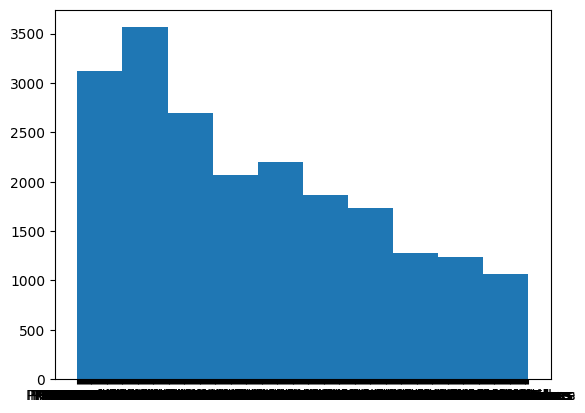

In [ ]:
plt.hist(df['Price'])
plt.show()

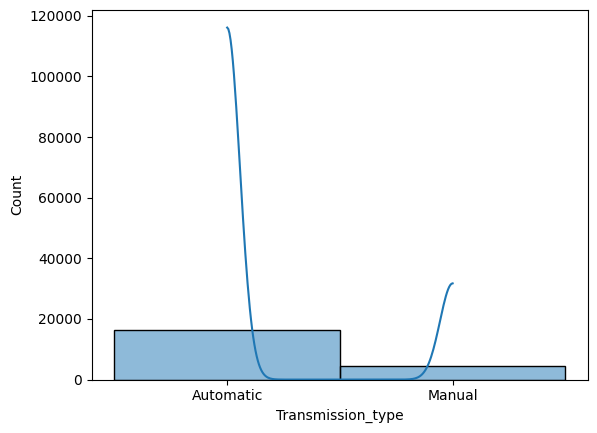

In [ ]:
sns.histplot(df['Transmission_type'],kde=True)
plt.show()

In [ ]:
df.head(2)

,Unnamed: 0,Title,Model,Fuel,Engine,Transmission_type,Location,Price
0,0,Audi e-tron 2021 for Sale,2021,Electric,95.0 kWh,Automatic,Lahore,PKR 2.65 crore
1,1,Audi e-tron 2021 for Sale,2021,Electric,95.0 kWh,Automatic,Lahore,PKR 2.65 crore


In [ ]:
print(df['Price'].unique())  #

['PKR 2.65 crore' 'PKR 2.32 crore' 'PKR 45.5 lacs' 'PKR 52.5 lacs'
 'PKR 15.95 lacs' 'PKR 12.9 lacs' 'PKR 2 crore' 'PKR 72 lacs'
 'PKR 50 lacs' 'PKR 31 lacs' 'PKR 60.25 lacs' 'PKR 33.49 lacs'
 'PKR 13.4 lacs' 'PKR 20.3 lacs' 'PKR 8.5 lacs' 'PKR 11.9 lacs'
 'PKR 46.3 lacs' 'PKR 52 lacs' 'PKR 17.5 lacs' 'PKR 4.2 lacs'
 'PKR 36.9 lacs' 'PKR 32.5 lacs' 'PKR 18 lacs' 'PKR 36 lacs'
 'PKR 1.55 crore' 'PKR 25.9 lacs' 'PKR 14.5 lacs' 'PKR 30.75 lacs'
 'PKR 31.5 lacs' 'PKR 29.75 lacs' 'PKR 34 lacs' 'PKR 83 lacs'
 'PKR 32.65 lacs' 'PKR 75 lacs' 'PKR 47 lacs' 'PKR 25.25 lacs'
 'PKR 9 lacs' 'PKR 24.5 lacs' 'PKR 45.25 lacs' 'PKR 29 lacs'
 'PKR 36.2 lacs' 'PKR 32 lacs' 'PKR 28 lacs' 'PKR 6 lacs' 'PKR 31.25 lacs'
 'PKR 12.65 lacs' 'PKR 18.9 lacs' 'PKR 46.5 lacs' 'PKR 60 lacs'
 'PKR 16.65 lacs' 'PKR 17.8 lacs' 'PKR 7.85 lacs' 'PKR 40 lacs'
 'PKR 4.95 lacs' 'PKR 25.88 lacs' 'PKR 9.8 lacs' 'PKR 12.6 lacs'
 'PKR 5.55 lacs' 'PKR 8.7 lacs' 'PKR 8 lacs' 'PKR 74 lacs' 'PKR 98 lacs'
 'PKR 20.85 lacs' 'PKR 58 l

In [ ]:
print(df['Location'].unique()) #nominal

['Lahore' 'Khanewal' 'Islamabad' 'Karachi' 'Peshawar' 'Faisalabad'
 'Hyderabad' 'Nowshera' 'Rawalpindi' 'Gujranwala' 'Multan' 'Sargodha'
 'Wah cantt' 'Karak' 'Mandi bahauddin' 'Bhera' 'Swabi' 'Sialkot'
 'Jaranwala' 'Kharian' 'D.G.Khan' 'Okara' 'Charsadda' 'Quetta'
 'Abbottabad' 'Hafizabad' 'Mirpur A.K.' 'Bahawalpur' 'Rahim Yar Khan'
 'Jhelum' 'Moro' 'Chakwal' 'Sukkur' 'Sara-E-Alamgir' 'Pano Aqil'
 'Kot addu' 'Gujrat' 'Mardan' 'Sahiwal' 'Dargai' 'Quaid Abad' 'Larkana'
 'Burewala' 'Gujar Khan' 'Sheikhupura' 'Nowshera cantt' 'Mansehra'
 'Chishtian' 'Liaqat Pur' 'Nankana sahib' 'Pir mahal' 'Jhang'
 'Muzaffar Gargh' 'Dina' 'Kamoke' 'Mandra' 'Taunsa sharif' 'Taxila'
 'Lala musa' 'Mangla' 'Fort Abbass' 'Akora khattak' 'Kamra' 'Bahawalnagar'
 'Toba Tek Singh' 'Layyah']


In [ ]:
print(df['Transmission_type'].unique())

['Automatic' 'Manual']


In [ ]:
print(df['Engine'].unique()) #

['95.0 kWh' '3500 cc' '1800 cc' '1500 cc' '1000 cc' '2000 cc' '3799 cc'
 '660 cc' '1300 cc' '1400 cc' '1600 cc' '2500 cc' '0.0 kWh' '2800 cc'
 '3400 cc' '800 cc' '4000 cc' '4600 cc' '100 cc' '2700 cc' '3000 cc'
 '5663 cc' '1200 cc' '4100 cc' '4200 cc' '4663 cc' '6400 cc' '2400 cc'
 '2100 cc' '4700 cc' '108 cc' '230.0 kWh' '600 cc' '60.0 kWh' '4500 cc'
 '6000 cc' '1198 cc' '10000 cc' '3200 cc' '5700 cc' '1100 cc']


In [ ]:
print(df['Fuel'].unique())

['Electric' 'Petrol' 'Hybrid' 'Diesel' 'CNG']


In [ ]:
print(df['Title'].unique())  #nominal

['Audi e-tron  2021  for Sale' 'Lexus RX Series  2017 450H for Sale'
 'Mercedes Benz C Class  2008 C200 for Sale'
 'Honda Vezel  2017 Hybrid RS Honda Sensing  for...'
 'Toyota Vitz  2002 FL 1.0 for Sale'
 'Suzuki Cultus  2016 EURO II for Sale'
 'Mercedes Benz E Class  2018 E200 Exclusive for...'
 'Mercedes Benz E Class Estate  2010 E 350 4MATI...'
 'Mercedes Benz S Class  2004  for Sale'
 'Changan Alsvin  2022 1.5L DCT Lumiere for Sale'
 'Honda Civic  2022  for Sale' 'Honda BR-V  2018 i-VTEC S for Sale'
 'Suzuki Wagon R  2011 Limited for Sale'
 'Honda City  2012 1.3 i-VTEC for Sale'
 'Suzuki Alto  2008 VXR (CNG) for Sale' 'Toyota Vitz  1999 F 1.0 for Sale'
 'KIA Stonic  2022 EX+ for Sale'
 'Honda Civic  2022 Oriel Prosmatec UG for Sale'
 'Suzuki Wagon R  2017 FX Limited for Sale'
 'Daihatsu Charade  1986 CX Turbo for Sale' 'Honda Civic  2018  for Sale'
 'Honda City  2020 Aspire Prosmatec 1.5 i-VTEC f...'
 'Honda Civic Eagle Eye 2005 VTi Oriel 1.6 for Sale'
 'Honda Vezel  2014 Hybrid Z 

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['Title']=le.fit_transform(df['Title'])
df['Location']=le.fit_transform(df['Location'])

In [ ]:
df['Transmission_type'].replace(['Automatic','Manual'],[0,1],inplace=True)
df['Fuel'].replace(['Electric','Petrol','Hybrid','Diesel','CNG'],[0,1,2,3,4],inplace=True)

/tmp/ipykernel_5243/518419037.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Transmission_type'].replace(['Automatic','Manual'],[0,1],inplace=True)
/tmp/ipykernel_5243/518419037.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Transmission_type'].replace(['Automatic','Manual'],[0,1],

In [ ]:
# split engine into two columns
df[['engine_value', 'engine_unit']] = df['Engine'].str.split(' ', expand=True)

# convert engine_value to numeric
df['engine_value'] = pd.to_numeric(df['engine_value'], errors='coerce')

# check result
print(df[['Engine', 'engine_value', 'engine_unit']].head())

     Engine  engine_value engine_unit
0  95.0 kWh          95.0         kWh
1  95.0 kWh          95.0         kWh
2   3500 cc        3500.0          cc
3  95.0 kWh          95.0         kWh
4   3500 cc        3500.0          cc


In [ ]:
df.head(3)

,Unnamed: 0,Title,Model,Fuel,Engine,Transmission_type,Location,Price,engine_value,engine_unit
0,0,10,2021,0,95.0 kWh,0,30,PKR 2.65 crore,95.0,kWh
1,1,10,2021,0,95.0 kWh,0,30,PKR 2.65 crore,95.0,kWh
2,2,194,2017,1,3500 cc,0,30,PKR 2.32 crore,3500.0,cc


In [ ]:
df.drop('Engine',axis=1,inplace=True)

In [ ]:
print(df['engine_unit'].unique())

['kWh' 'cc']


In [ ]:
df['engine_unit'].replace(['kWh','cc'],[0,1],inplace=True)

/tmp/ipykernel_5243/234183002.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['engine_unit'].replace(['kWh','cc'],[0,1],inplace=True)
/tmp/ipykernel_5243/234183002.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['engine_unit'].replace(['kWh','cc'],[0,1],inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20822 entries, 0 to 20821
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         20822 non-null  int64  
 1   Title              20822 non-null  int64  
 2   Model              20822 non-null  int64  
 3   Fuel               20822 non-null  int64  
 4   Transmission_type  20822 non-null  int64  
 5   Location           20822 non-null  int64  
 6   Price              20822 non-null  object 
 7   engine_value       20822 non-null  float64
 8   engine_unit        20822 non-null  int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 1.4+ MB


In [ ]:
import numpy as np

def convert_price(x):
    if x == 'Call':
        return np.nan

    x = x.replace('PKR', '').strip()

    if 'crore' in x:
        return float(x.replace('crore', '').strip()) * 10000000
    elif 'lacs' in x:
        return float(x.replace('lacs', '').strip()) * 100000
    else:
        return np.nan

df['price_pkr'] = df['Price'].apply(convert_price)

In [ ]:
df.drop('Price',axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20822 entries, 0 to 20821
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         20822 non-null  int64  
 1   Title              20822 non-null  int64  
 2   Model              20822 non-null  int64  
 3   Fuel               20822 non-null  int64  
 4   Transmission_type  20822 non-null  int64  
 5   Location           20822 non-null  int64  
 6   engine_value       20822 non-null  float64
 7   engine_unit        20822 non-null  int64  
 8   price_pkr          19843 non-null  float64
dtypes: float64(2), int64(7)
memory usage: 1.4 MB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Title,0
Model,0
Fuel,0
Transmission_type,0
Location,0
engine_value,0
engine_unit,0
price_pkr,979


In [ ]:
df['price_pkr']=df['price_pkr'].fillna(0)

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Title,0
Model,0
Fuel,0
Transmission_type,0
Location,0
engine_value,0
engine_unit,0
price_pkr,0


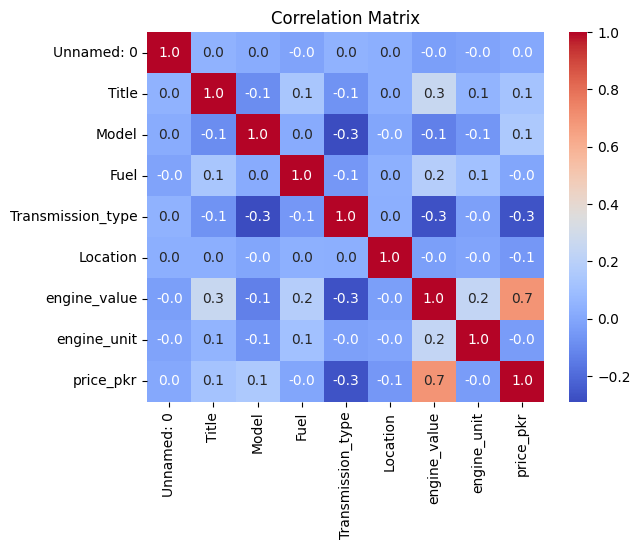

In [ ]:
corr_matrix=df.corr()

sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

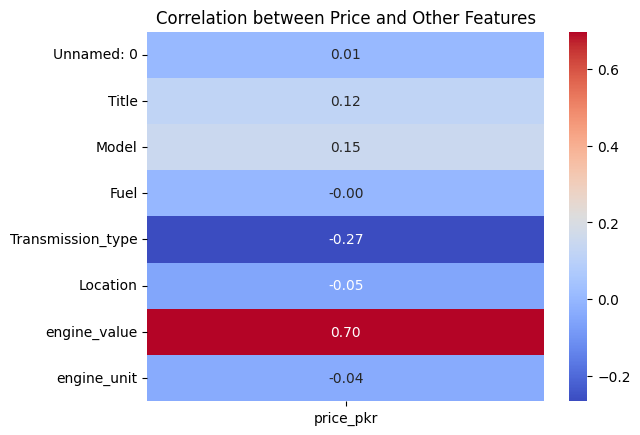

In [ ]:
price_corr=df.corr()['price_pkr']
price_corr=price_corr.drop('price_pkr')

sns.heatmap(price_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',cbar=True,annot_kws={'size':10})
plt.title('Correlation between Price and Other Features')
plt.show()

In [ ]:
df.drop(['Unnamed: 0','Fuel','engine_unit'],axis=1,inplace=True)

<Axes: >

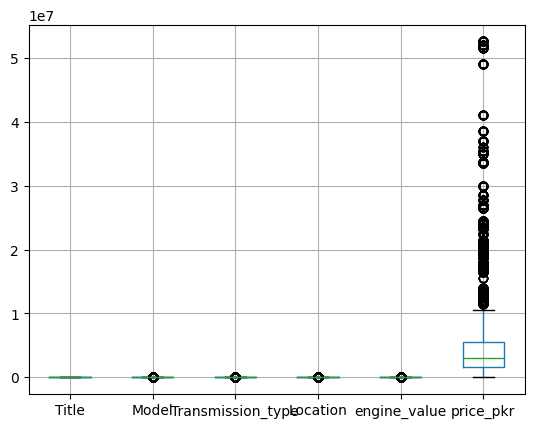

In [ ]:
df.boxplot()

In [ ]:
df.shape

(20822, 6)

In [ ]:
def remove_outlier_iqr(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
      continue
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr

    df=df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]
  return df

df_cleaned=remove_outlier_iqr(df,exclude_column='price_pkr')
df=df_cleaned

In [ ]:
df.shape

(12245, 6)

In [ ]:
print(df.columns)

Index(['Title', 'Model', 'Transmission_type', 'Location', 'engine_value',
       'price_pkr'],
      dtype='object')


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features=['Title','Model','Transmission_type','Location','engine_value']

scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled_data,columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=df[['Title','Model','Transmission_type','Location','engine_value']]
y=df['price_pkr']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=LinearRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=model.score(x_test,y_test)
print(f'Baseline model accuracy:{accuracy:.2f}')

Baseline model accuracy:0.20


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import accuracy_score
import pandas as pd

x=df[['Title','Model','Transmission_type','Location','engine_value']]
y=df['price_pkr']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=SVR(kernel='poly',degree=8)
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=model.score(x_test,y_test)
print(f'Baseline model accuracy:{accuracy:.2f}')

Baseline model accuracy:0.04
